# $\color{#dda}{\text{Héctor Alonso Heredia Pérez}}$

# Análisis

## Análisis Descriptivo
- Realizar un análisis descriptivo de cada variable verificando:
  - Tipo de dato
  - Distribución
- Generar una comparación bivariada entre cada variable y la variable de respuesta `es_fraude`
- Realizar mean encoding para cada categoría en variables categóricas:
  - Propósito: Identificar qué variables pueden ser relevantes para predecir `es_fraude`
  - Conclusiones: [Incluir observaciones sobre las variables más relevantes]

## PCA (Análisis de Componentes Principales)
- Generar un PCA de 3 dimensiones y visualizarlo gráficamente
  - ¿Se observan clústers a simple vista?
- Descripción del PCA:
  - Qué es: Técnica de reducción de dimensionalidad
  - Cómo funciona: Transforma los datos a un nuevo sistema de coordenadas ordenado por varianza explicada
  - Utilidad: Para visualización, reducción de ruido y preprocesamiento

# Feature Engineering

## Generación de Nuevas Variables
1. **Variable 1**: [Nombre]
   - Hipótesis: [Explicación de por qué esta variable podría ser relevante]
   - Análisis bivariado con `es_fraude`
   - Conclusión: [¿Es útil o no?]

2. **Variable 2**: [Nombre]
   - Hipótesis: [Explicación de por qué esta variable podría ser relevante]
   - Análisis bivariado con `es_fraude`
   - Conclusión: [¿Es útil o no?]

# Encoding

## Método WoE (Weight of Evidence)
- Aplicar WoE para encoding de variables categóricas
- Descripción:
  - Cómo funciona: Transforma categorías en valores numéricos basados en la relación con la variable objetivo
  - Intuición matemática: Logaritmo del ratio entre distribución de eventos y no eventos
  - Interpretación: Valores positivos indican mayor asociación con fraude, negativos con no fraude

# Reducción de Variables

## Método Aplicado: [Seleccionar entre varianza, correlaciones o coeficientes de regresión logística]
- Teoría: [Explicación del método seleccionado]
- Utilidad: [Para qué sirve y cómo ayuda en el modelo]
- Resultados: [Variables eliminadas/mantenidas y justificación]

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [ ]:
data = pd.read_csv('evaluacion_final.csv', index_col="Unnamed: 0")

In [112]:
data

,estatura,estado_de_nacimiento,tiempo_de_aplicacion_en_minutos,salario,meses_de_existencia_del_email,antiguedad_de_linea_telefono_en_meses,signo_zodiacal,dependientes_economicos,autocalificacion,edad,es_fraude
0,1.516338,Baja California,36.159325,1469.510205,61.632958,94.289586,libra,2.056061,no me tengo confianza,42.099828,1
1,1.550566,Jalisco,61.188959,3247.437691,78.011940,76.216707,géminis,1.836817,le echo ganas,42.323934,0
2,1.565494,Chiapas,38.517943,2497.792119,84.518561,81.396224,capricornio,2.491207,le echo ganas,38.830773,1
3,1.535704,Nuevo León,48.504826,2120.839442,52.249868,92.662409,capricornio,2.577344,no me tengo confianza,43.184403,1
4,1.638269,Jalisco,66.079192,3212.457463,64.703729,91.593946,capricornio,1.781526,le echo ganas,41.375459,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.551369,Nuevo León,26.041746,2540.637605,59.781489,102.493683,capricornio,2.005929,le echo ganas,49.741298,1
9996,1.600764,Nuevo León,38.293141,2577.097714,39.014350,88.780881,géminis,1.406488,le echo ganas,41.396081,1
9997,1.609818,Nuevo León,12.483618,1475.337424,27.335385,130.830064,capricornio,2.183786,le echo ganas,45.811748,0
9998,1.510276,Nuevo León,50.395354,2351.819000,39.243611,46.884518,libra,2.315403,le echo ganas,44.978843,1


# $\color{#dda}{\text{Análisis}}$

### $\color{#dda}{\text{Análisis descriptivo}}$

- Realizar un análisis descriptivo de cada variable verificando:
  - Tipo de dato
  - Distribución

In [113]:
data_info = data.describe(include='all')
data_types = data.dtypes
print(data_info)
print(data_types)

            estatura estado_de_nacimiento  tiempo_de_aplicacion_en_minutos  \
count   10000.000000                10000                     10000.000000   
unique           NaN                    6                              NaN   
top              NaN              Jalisco                              NaN   
freq             NaN                 4925                              NaN   
mean        1.603226                  NaN                        51.297967   
std         0.067391                  NaN                        19.001127   
min         1.300000                  NaN                         1.000000   
25%         1.558184                  NaN                        36.693869   
50%         1.602361                  NaN                        47.946915   
75%         1.649776                  NaN                        65.369716   
max         1.850000                  NaN                       120.000000   

             salario  meses_de_existencia_del_email  \
count   

### $\color{#dda}{\text{Comparación bivariada}}$

- Generar una comparación bivariada entre cada variable y la variable de respuesta `es_fraude`

In [114]:
categorical_columns = ['estado_de_nacimiento', 'signo_zodiacal', 'autocalificacion']
numerical_columns = ['estatura', 'tiempo_de_aplicacion_en_minutos', 'salario', 
                     'meses_de_existencia_del_email', 'antiguedad_de_linea_telefono_en_meses', 
                     'dependientes_economicos', 'edad']

### $\color{#dda}{\text{Mean encoding}}$

- Realizar mean encoding para cada categoría en variables categóricas:
  - Propósito: Identificar qué variables pueden ser relevantes para predecir `es_fraude`
  - Conclusiones: [Incluir observaciones sobre las variables más relevantes]

In [115]:
def mean_encoding(df, categorical_columns, target_column):
    encoding_dict = {}
    for column in categorical_columns:
        encoding_dict[column] = df.groupby(column)[target_column].mean()
        df[column] = df[column].map(encoding_dict[column])
    return df

# Aplicar Mean Encoding en las variables categóricas
data_encoded = mean_encoding(data, categorical_columns, 'es_fraude')

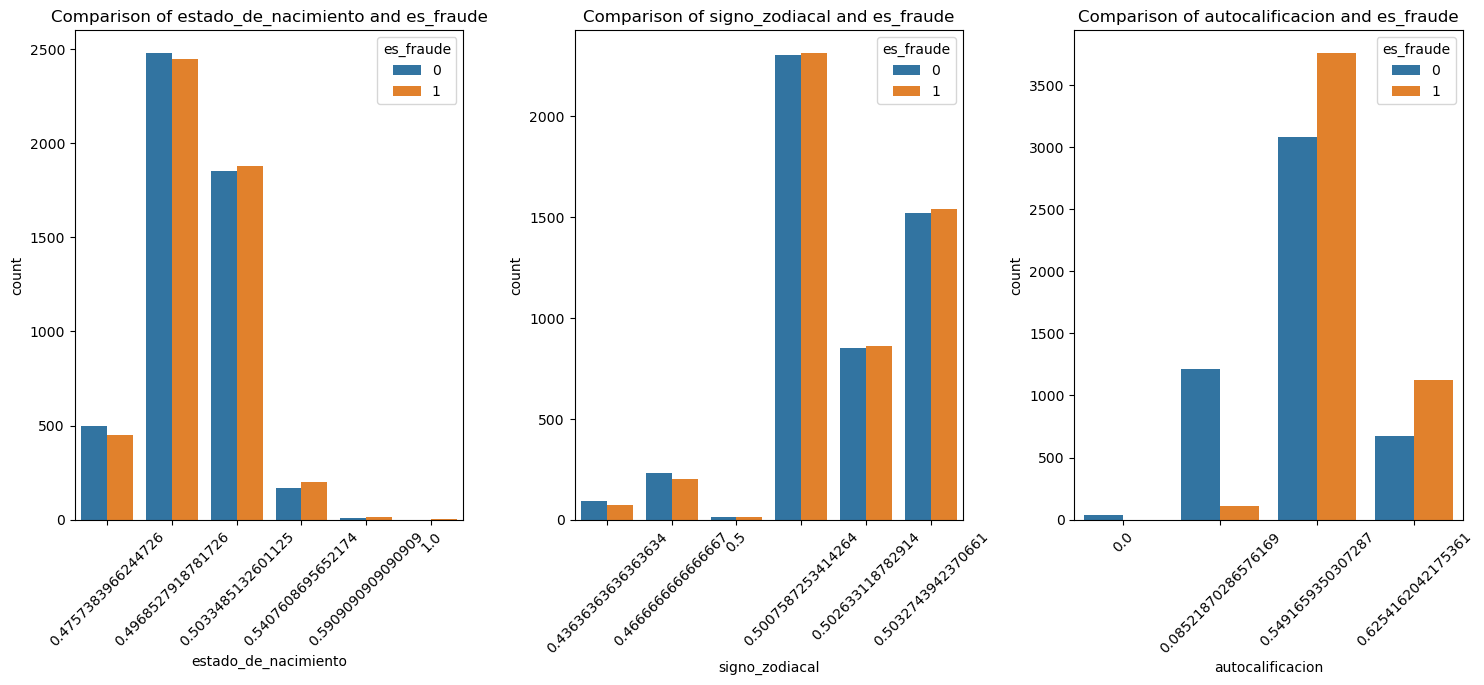

In [ ]:
plt.figure(figsize=(15, 12))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=data, x=column, hue='es_fraude')
    plt.title(f'Comparison of {column} and es_fraude')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

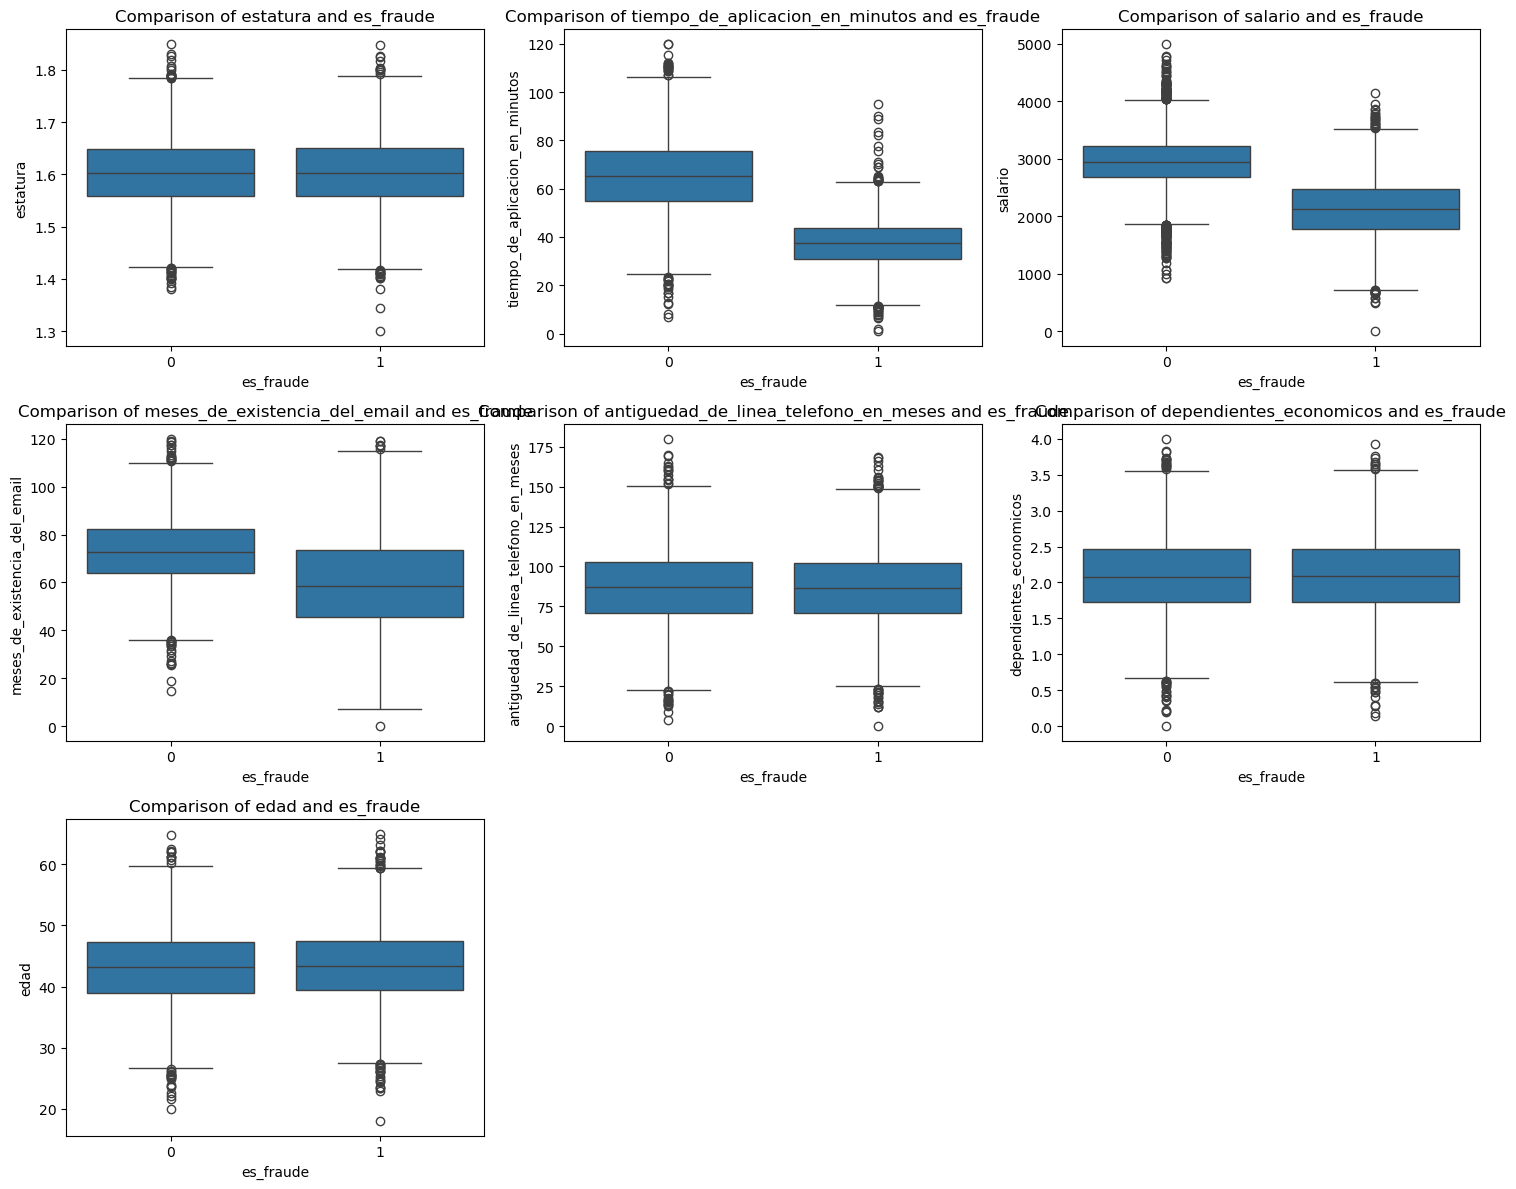

In [117]:
# Gráficos de comparación bivariada para variables numéricas
plt.figure(figsize=(15, 12))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=data, x='es_fraude', y=column)
    plt.title(f'Comparison of {column} and es_fraude')
plt.tight_layout()
plt.show()

### $\color{#dda}{\text{PCA}}$

- Generar un PCA de 3 dimensiones y visualizarlo gráficamente
  - ¿Se observan clústers a simple vista?
    - Sí, bastante marcados
- Descripción del PCA:
  - Qué es: Técnica de reducción de dimensionalidad
  - Cómo funciona: Transforma los datos a un nuevo sistema de coordenadas ordenado por varianza explicada
  - Utilidad: Para visualización, reducción de ruido y preprocesamiento

In [118]:
# Selección de variables numéricas
numerical_data = data[numerical_columns]
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

# PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(numerical_scaled)

# Crear DataFrame con los resultados de PCA
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2', 'PCA3'])
pca_df['es_fraude'] = data['es_fraude']

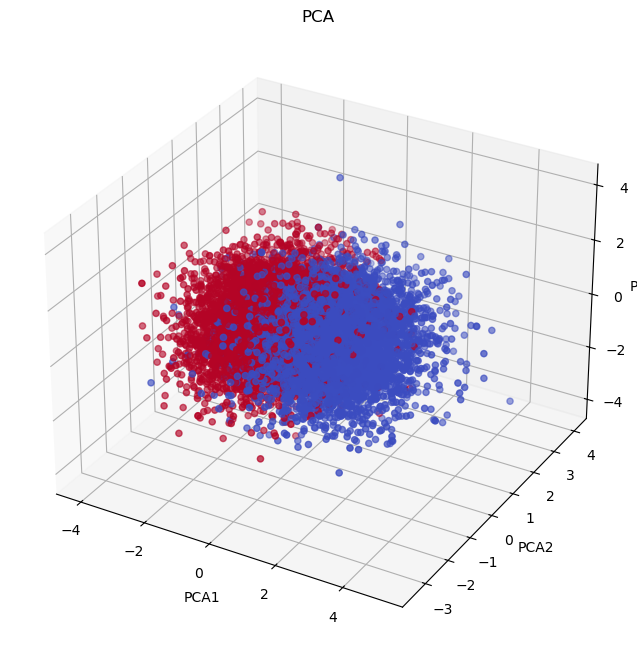

In [119]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_df['PCA1'], pca_df['PCA2'], pca_df['PCA3'], c=pca_df['es_fraude'], cmap='coolwarm')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.title('PCA')
plt.show()

### $\color{#dda}{\text{Feature Engineering}}$

1. **Variable 1**: [edad_al_contratar]
    - Hipótesis: Esta variable podría ser relevante porque la edad al momento de registrar un email puede indicar el momento en el que alguien comienza a formar parte del mundo del internet, o si fue creado en una edad avanzada, esto indicaría que ya formaba parte y que por una u otra razón necesita otro mail.
    - Análisis bivariado con es_fraude: No se observan grandes diferencias entre las clases de fraude y no fraude en esta variable.
    - Conclusión: No es útil. La edad al contratar no tiene una relación clara con el fraude.

2. **Variable 2**: [salario_por_dependiente]
    - Hipótesis: Las personas con más dependientes económicos pueden tener un salario proporcionalmente más bajo, lo que podría estar asociado con una mayor probabilidad de fraude debido a situaciones financieras difíciles.
    - Análisis bivariado con es_fraude: Hay una diferencia en la distribución entre fraude y no fraude, lo que sugiere que las personas con más dependientes económicos podrían estar más asociadas al fraude.
    - Conclusión: Es útil. Esta variable muestra una relación más clara con el fraude y podría ser relevante para la predicción.

3. **Variable 3**: [email_nuevo_o_viejo]
    - Hipótesis: Los emails nuevos podrían estar más asociados al fraude, ya que los estafadores a menudo crean nuevas cuentas de correo.
    - Análisis bivariado con es_fraude: Muchos de los casos de fraude tienen emails nuevos, lo que sugiere una fuerte relación con el fraude.
    - Conclusión: Parece ser altamente útil. Esta variable podría ser una fuerte indicadora de fraude.


Quise hacer una utilizando autocalificación, niveles de por ejemplo, pero realmente no reflejaba de manera tan precisa y no podía combinarlo con nada.

También probé experimentando con muchas variables combinando con edad o salario, pero no me funcionó tan bien.

In [120]:
data['email_nuevo_o_viejo'] = np.where(data['meses_de_existencia_del_email'] < 12, 'Nuevo', 'Viejo')
data['edad_al_contratar'] = data['edad'] - data['meses_de_existencia_del_email'] / 12
data['salario_por_dependiente'] = data['salario'] / (data['dependientes_economicos'] + 1)

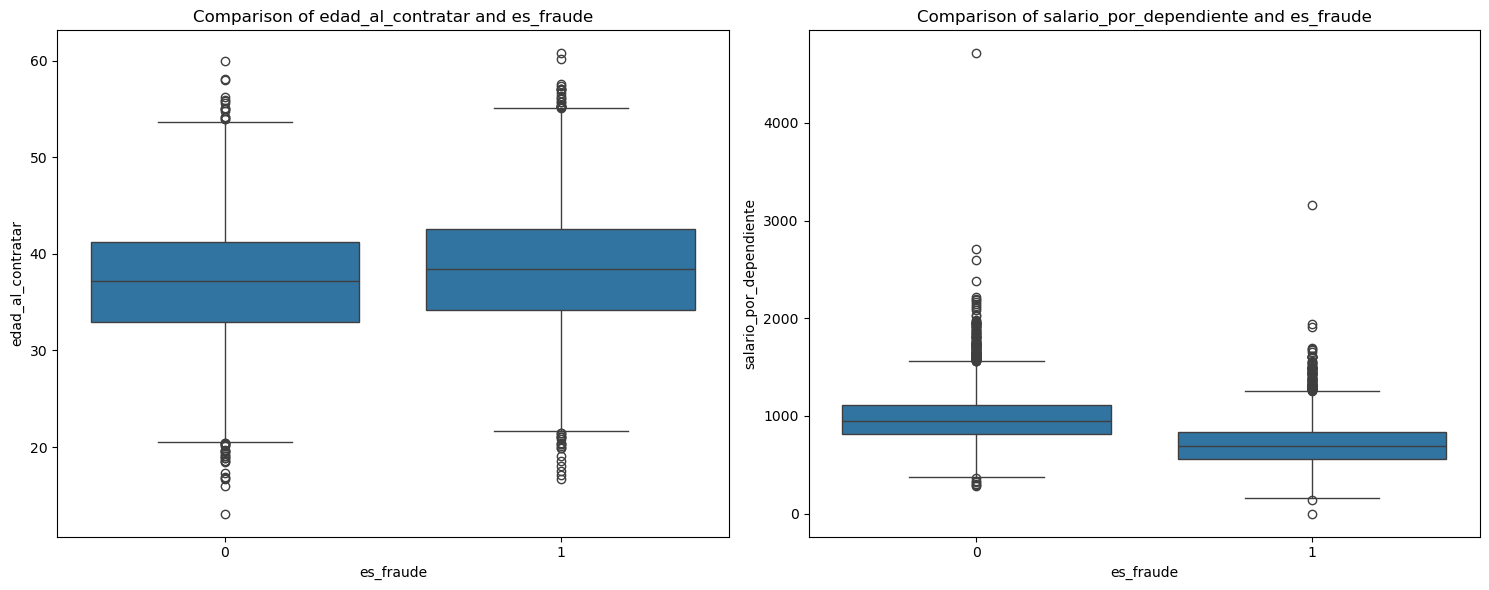

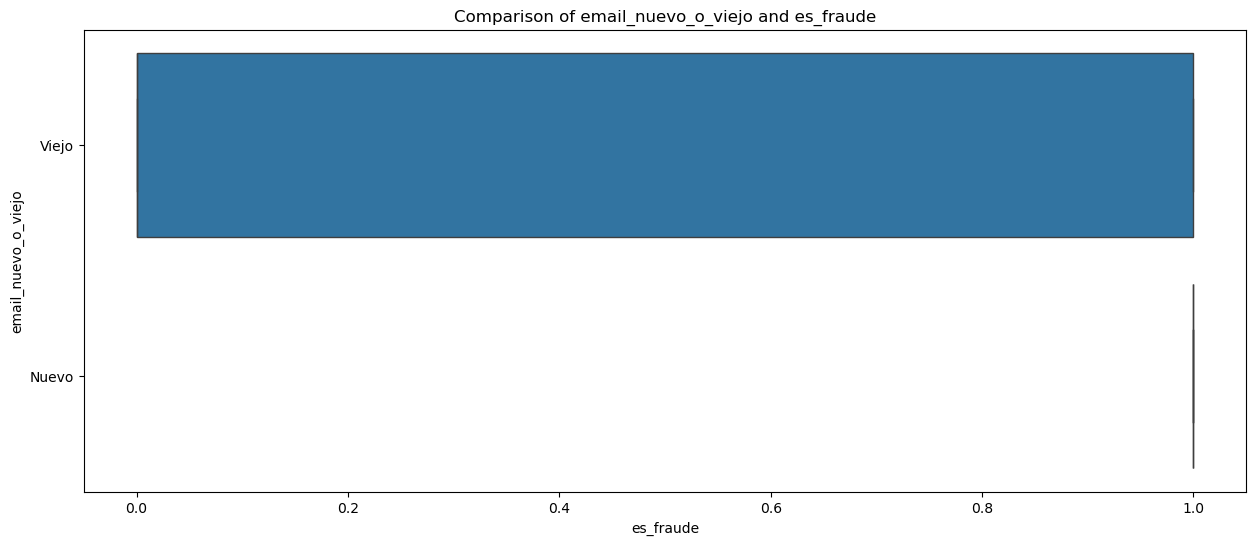

In [121]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='es_fraude', y='edad_al_contratar')
plt.title('Comparison of edad_al_contratar and es_fraude')

plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='es_fraude', y='salario_por_dependiente')
plt.title('Comparison of salario_por_dependiente and es_fraude')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='es_fraude', y='email_nuevo_o_viejo')
plt.title('Comparison of email_nuevo_o_viejo and es_fraude')
plt.show()

### $\color{#dda}{\text{Encoding}}$

- Aplicar WoE para encoding de variables categóricas
- Descripción:
  - Cómo funciona: Transforma categorías en valores numéricos basados en la relación con la variable objetivo
  - Intuición matemática: Logaritmo del ratio entre distribución de eventos y no eventos
  - Interpretación: Valores positivos indican mayor asociación con fraude, negativos con no fraude

In [122]:
def woE_encoding(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['mean', 'count'])
    grouped['woe'] = np.log(grouped['mean'] / grouped['mean'].mean())
    return grouped['woe'].to_dict()

variables_woe = ['email_nuevo_o_viejo', 'autocalificacion'] # Son las cats que podrían tener mejores resultados

for var in variables_woe:
    woe_dict = woE_encoding(data, var, 'es_fraude')
    data[f'{var}_woe'] = data[var].map(woe_dict)


c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


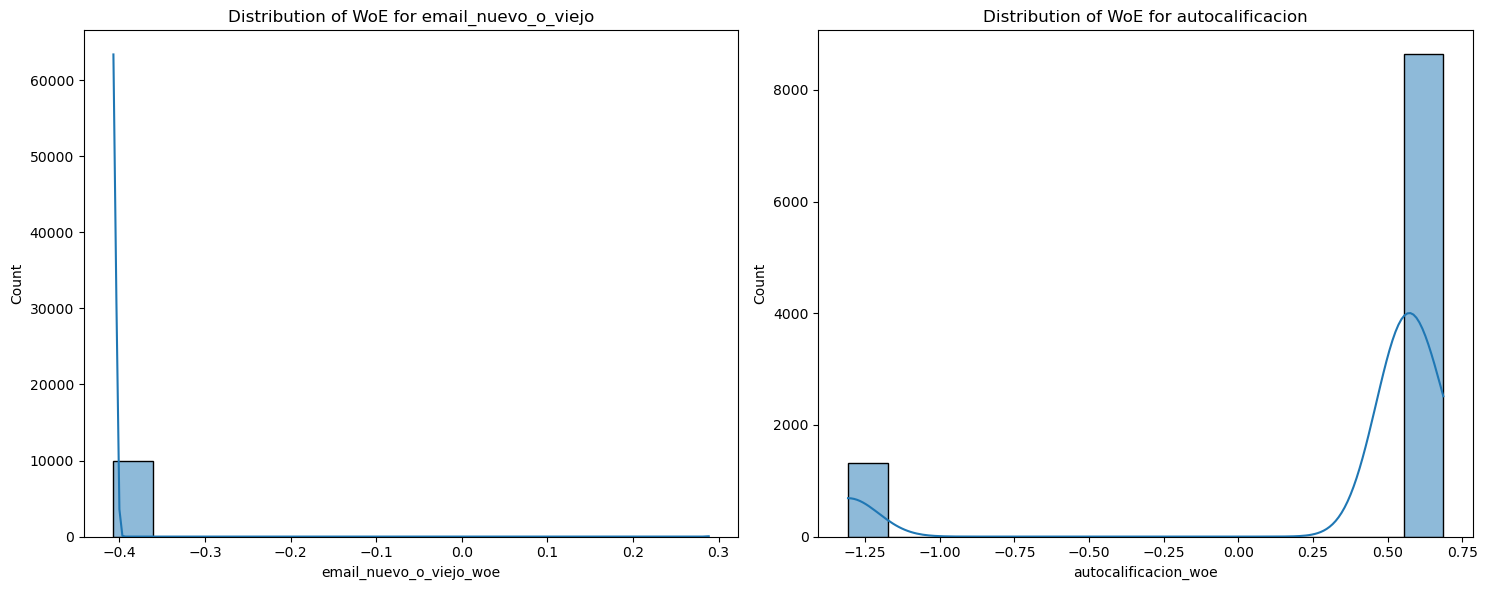

In [123]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data['email_nuevo_o_viejo_woe'], kde=True)
plt.title('Distribution of WoE for email_nuevo_o_viejo')

plt.subplot(1, 2, 2)
sns.histplot(data['autocalificacion_woe'], kde=True)
plt.title('Distribution of WoE for autocalificacion')

plt.tight_layout()
plt.show()

Parece que ambas tienen sesgo, email nuevo o viejo más que autocalificacion. En general parece que podrían ser buenas indicadoras.

### $\color{#dda}{\text{Reducción de Variables}}$

#### Método Aplicado: [correlaciones]
- Teoría: El análisis de correlación mide la relación entre dos variables. Si dos variables están altamente correlacionadas (por ejemplo, con una correlación mayor a 0.68), esto puede indicar redundancia en la información que aportan al modelo. La multicolinealidad que resulta de esto puede hacer que el modelo sea inestable y más propenso a sobreajuste. Por lo tanto, es beneficioso eliminar una de las variables altamente correlacionadas para mejorar la estabilidad y rendimiento del modelo.

- Utilidad: Este método permite eliminar variables redundantes, lo que reduce la multicolinealidad y mejora la generalización del modelo. Al hacerlo, las variables restantes se vuelven más estables y se reduce el sobreajuste.

- Resultados:

    - Variables eliminadas:

            edad_al_contratar: Debido a la correlación baja con es_fraude y su posible redundancia con otras variables.

            salario_por_dependiente: Eliminada por alta correlación con salario y no aportar nueva información significativa.

            estatura: No está correlacionada de manera significativa con es_fraude.

            antiguedad_de_linea_telefono_en_meses: Baja correlación con `es_fraude.

            dependientes_economicos: Correlación baja y no aporta nueva información.

            edad: Baja correlación con la variable objetivo.

            email_nuevo_o_viejo_woe: Ya transformada, pero con correlación alta con email_nuevo_o_viejo.

            signo_zodiacal: Variables categóricas irrelevantes sin relación significativa con es_fraude.

            estado_de_nacimiento: Sin correlación significativa y eliminado como variable irrelevante.

    - Variables mantenidas:

            tiempo_de_aplicacion_en_minutos: Relación moderada con es_fraude, útil en el modelo.

            salario: Variable clave para la predicción de fraude.

            meses_de_existencia_del_email: Relación significativa con es_fraude.

            autocalificacion_woe: Transformación útil de una variable categórica, relevante para la predicción.

In [124]:
data.head(10)

,estatura,estado_de_nacimiento,tiempo_de_aplicacion_en_minutos,salario,meses_de_existencia_del_email,antiguedad_de_linea_telefono_en_meses,signo_zodiacal,dependientes_economicos,autocalificacion,edad,es_fraude,email_nuevo_o_viejo,edad_al_contratar,salario_por_dependiente,email_nuevo_o_viejo_woe,autocalificacion_woe
0,1.516338,0.475738,36.159325,1469.510205,61.632958,94.289586,0.503274,2.056061,0.625416,42.099828,1,Viejo,36.963748,480.851000,-0.406868,0.686003
1,1.550566,0.496853,61.188959,3247.437691,78.011940,76.216707,0.502633,1.836817,0.549166,42.323934,0,Viejo,35.822939,1144.747039,-0.406868,0.555986
2,1.565494,0.540761,38.517943,2497.792119,84.518561,81.396224,0.500759,2.491207,0.549166,38.830773,1,Viejo,31.787560,715.452391,-0.406868,0.555986
3,1.535704,0.503349,48.504826,2120.839442,52.249868,92.662409,0.500759,2.577344,0.625416,43.184403,1,Viejo,38.830247,592.853061,-0.406868,0.686003
4,1.638269,0.496853,66.079192,3212.457463,64.703729,91.593946,0.500759,1.781526,0.549166,41.375459,0,Viejo,35.983482,1154.926225,-0.406868,0.555986
5,1.489631,0.503349,54.400157,2551.519793,62.136014,102.177236,0.503274,1.457302,0.625416,32.081737,1,Viejo,26.903736,1038.342119,-0.406868,0.686003
6,1.692909,0.496853,58.588700,3060.135995,69.236188,104.266023,0.500759,0.577356,0.549166,46.541536,0,Viejo,40.771854,1940.041700,-0.406868,0.555986
7,1.662173,0.540761,41.628862,1616.849382,64.438612,108.066494,0.466667,2.989663,0.625416,34.825366,1,Viejo,29.455482,405.259685,-0.406868,0.686003
8,1.686080,0.475738,46.688903,2750.249261,32.285172,138.853697,0.500759,2.149263,0.549166,46.009702,1,Viejo,43.319271,873.299303,-0.406868,0.555986
9,1.775053,0.503349,72.579028,2831.737182,59.479357,140.050511,0.500759,1.324118,0.549166,41.809224,0,Viejo,36.852611,1218.413650,-0.406868,0.555986


In [126]:
def woE_encoding(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['mean', 'count'])
    grouped['woe'] = np.log(grouped['mean'] / grouped['mean'].mean())
    return grouped['woe'].to_dict()

# Aplicar WoE a las cats
categorical_vars = ['email_nuevo_o_viejo', 'autocalificacion']
for var in categorical_vars:
    woe_dict = woE_encoding(data, var, 'es_fraude')
    data[f'{var}_woe'] = data[var].map(woe_dict)

# Eliminar las variables originales de tipo string
data = data.drop(columns=categorical_vars)

corr_matrix = data.corr()


c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


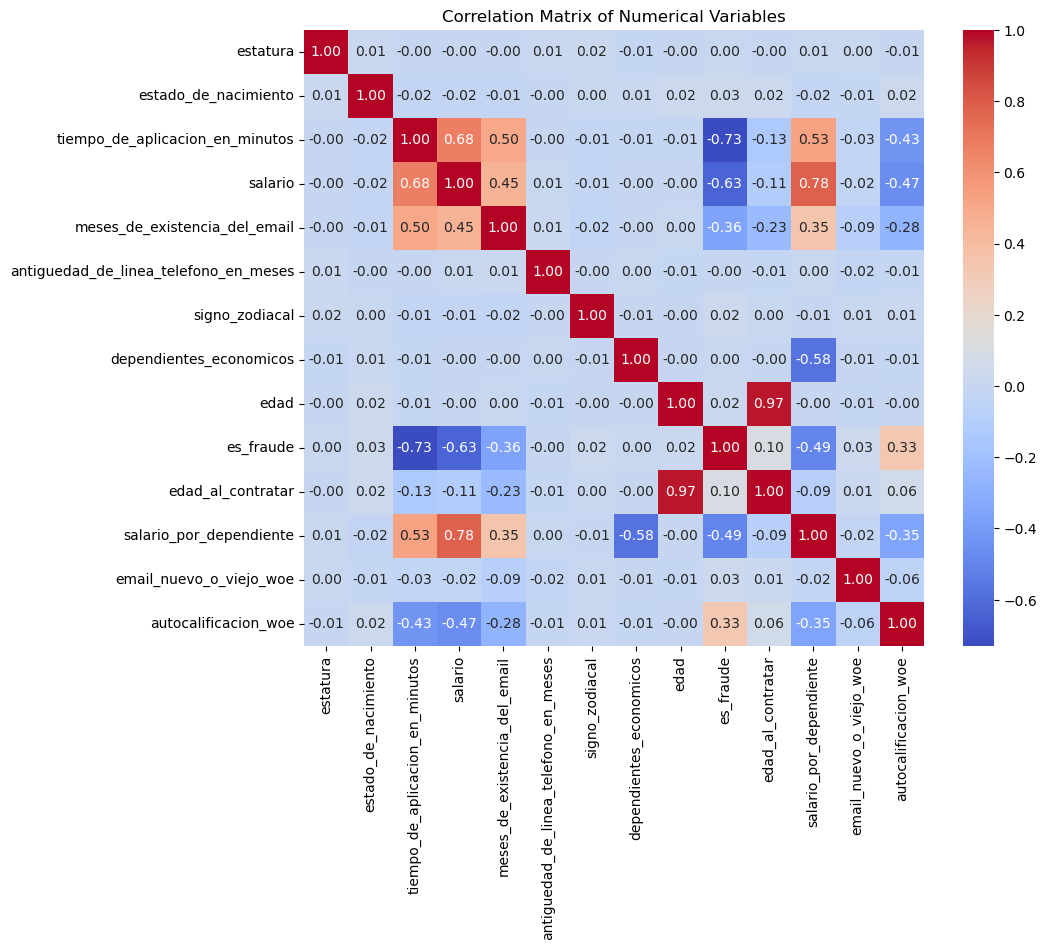

In [127]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [128]:
threshold = 0.68
# Encontrar las variables que están altamente correlacionadas
high_corr_var = np.where(corr_matrix > threshold)
high_corr_var = [(data.columns[x], data.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

# Eliminar las variables de alta correlación
columns_to_drop = []
for var1, var2 in high_corr_var:
    columns_to_drop.append(var2)  # Eliminar una de las dos variables correlacionadas

# Asegurarse de que las variables a eliminar no sean duplicadas
columns_to_drop = list(set(columns_to_drop))

# Eliminar las variables del dataframe
data_reduced = data.drop(columns=columns_to_drop)

# Eliminar variables categóricas irrelevantes
categorical_vars = ['signo_zodiacal', 'estado_de_nacimiento']  # Variables irrelevantes
data_reduced = data_reduced.drop(columns=categorical_vars)

# Eliminar variables con baja correlación con 'es_fraude'
numerical_vars = ['estatura', 'tiempo_de_aplicacion_en_minutos', 'salario', 
                  'meses_de_existencia_del_email', 'antiguedad_de_linea_telefono_en_meses', 
                  'dependientes_economicos', 'edad', 'edad_al_contratar', 
                  'salario_por_dependiente', 'email_nuevo_o_viejo_woe', 'autocalificacion_woe']

# Revisar la correlación con 'es_fraude' y eliminar variables con correlación baja (menor a 0.1)
corr_with_target = data[numerical_vars].corrwith(data['es_fraude'])
low_corr_vars = corr_with_target[corr_with_target.abs() < 0.1].index.tolist()

# Eliminar las variables con baja correlación
data_reduced = data_reduced.drop(columns=low_corr_vars)

corr_matrix_reduced = data_reduced.corr()


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


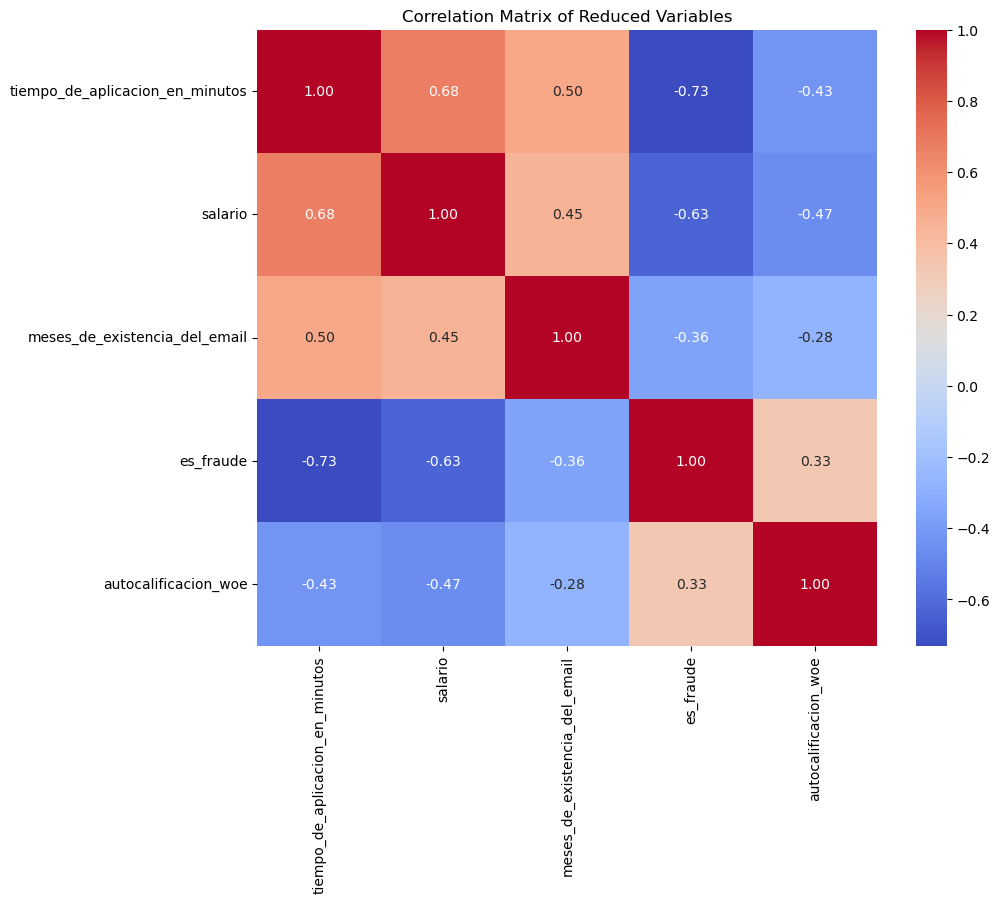

Variables eliminadas: ['edad_al_contratar', 'salario_por_dependiente', 'estatura', 'antiguedad_de_linea_telefono_en_meses', 'dependientes_economicos', 'edad', 'email_nuevo_o_viejo_woe', 'signo_zodiacal', 'estado_de_nacimiento']
Variables restantes: ['tiempo_de_aplicacion_en_minutos', 'salario', 'meses_de_existencia_del_email', 'es_fraude', 'autocalificacion_woe']


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_reduced, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Reduced Variables')
plt.show()

print(f"Variables eliminadas: {columns_to_drop + low_corr_vars + categorical_vars}")
print(f"Variables restantes: {data_reduced.columns.tolist()}")